In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\scenarioA_embed.csv")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
X = data.iloc[:,0:50].values
Y = data.iloc[:,50].values
Y = Y.reshape(-1,1)

X = torch.tensor(
    X,
    dtype=torch.float32
)

Y = torch.tensor(
    Y,
    dtype=torch.long
)

X = X[:,:,None] # 變tensor

print(X.shape)
print(Y.shape)

torch.Size([500, 50, 1])
torch.Size([500, 1])


In [5]:
class SelfAttention(nn.Module):

    def __init__(self, d_k):
        super().__init__()

        self.Wq = nn.Linear(1,d_k)
        self.Wk = nn.Linear(1,d_k)
        self.Wv = nn.Linear(1,d_k)


    def forward(self,x):

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)


        scores = torch.matmul(
            Q,
            K.transpose(1,2)
        )


        scores = scores / np.sqrt(Q.shape[-1])


        attention_weights = torch.softmax(
            scores,
            dim=-1
        )


        output = torch.matmul(
            attention_weights,
            V
        )


        return output, attention_weights

In [7]:
class AttentionRegression(nn.Module):

    def __init__(self):
        super().__init__()

        self.attention = SelfAttention(
            d_k=8
        )

        self.fc = nn.Linear(
            50*8,
            1
        )


    def forward(self,x):

        out, att = self.attention(x)

        out = out.reshape(
            x.shape[0],
            -1
        )

        prediction = self.fc(out)

        return prediction, att

In [10]:
model = AttentionRegression()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


for epoch in range(100):

    optimizer.zero_grad()


    pred, attention = model(X)


    loss = criterion(
        pred,
        Y
    )


    loss.backward()


    optimizer.step()


    if epoch%10==0:
        print(
            epoch,
            loss.item()
        )

0 2533.029052734375
10 387.5994873046875
20 99.4764633178711
30 19.576831817626953
40 31.640636444091797
50 14.683364868164062
60 9.009296417236328
70 8.045455932617188
80 7.890948295593262
90 7.84650182723999


In [12]:
model.eval()

with torch.no_grad():
    pred, attention = model(X)

att0 = attention[0].cpu().numpy()

print(att0)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


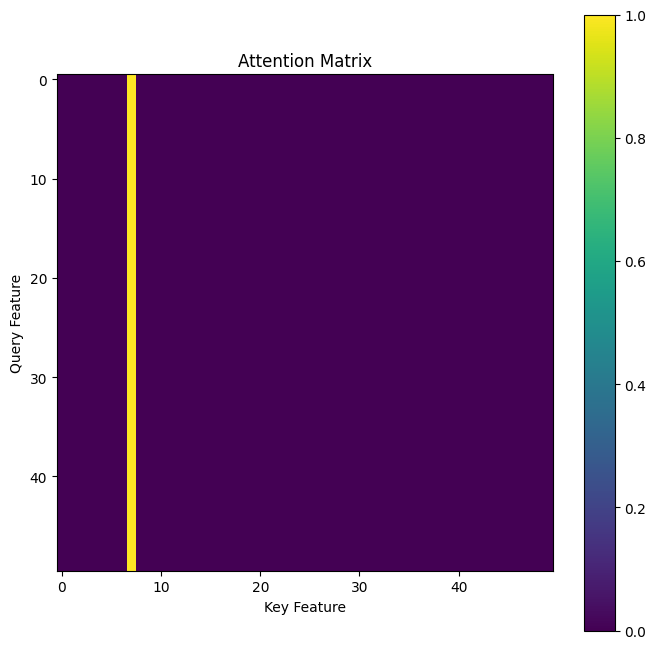

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.imshow(
    att0,
    cmap="viridis"
)

plt.colorbar()

plt.xlabel("Key Feature")

plt.ylabel("Query Feature")

plt.title("Attention Matrix")

plt.show()

In [14]:
print(attention.shape)

torch.Size([500, 50, 50])
